In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
# Colab-only mounting; safely skipped if not in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    # Running outside Colab (e.g., local Jupyter) – skip mounting
    pass

Mounted at /content/drive


In [4]:
# If running in Colab, file will be in Google Drive; locally, use current directory
import os

if os.path.exists('/content/drive/My Drive/English-Hindi.tsv'):
    file_path = '/content/drive/My Drive/English-Hindi.tsv'
else:
    file_path = 'English-Hindi.tsv'

In [5]:
df = pd.read_csv(
    file_path,
    sep='\t',
    header=None,
    names=["id1","en","id2","hi"]
)

df.head()

,id1,en,id2,hi
0,1282,Muiriel is 20 now.,485968,म्यूरियल अब बीस साल की हो गई है।
1,1282,Muiriel is 20 now.,2060319,म्यूरियल अब बीस साल की है।
2,1294,Education in this world disappoints me.,485564,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,1302,That won't happen.,2060320,वैसा नहीं होगा।
4,1308,I miss you.,2060321,मुझें तुम्हारी याद आ रही है।


In [8]:
# # Load the TSV dataset
# df = pd.read_csv('English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])

In [6]:
# Show a sample
df.sample(5)

,id1,en,id2,hi
10077,462592,The books are on the table.,4156360,किताबें मेज़ पर हैं।
10831,7357090,"Sir, I'm looking for a job.",8685604,"साहब, मैं नौकरी ढूँढ रहा हूँ।"
8828,278468,There are a lot of flowers in the garden.,4042853,बगीचे में बहुत सारे फूल हैं।
7968,1010094,Let's meet at five.,2039262,पाँच बजे मिलते हैं।
9115,60099,Can you sing this song?,4062982,क्या तुम यह गाना गा सकते हो?


In [7]:
# Keep only the English and Hindi columns
df = df[["en", "hi"]]

In [8]:
# Drop any rows with missing data
df.dropna(inplace=True)

In [9]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [10]:
# Preview cleaned d
# ata
df.head()

,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [11]:
# Number of sentence pairs
print("Total pairs:", len(df))

Total pairs: 13186


In [12]:
# Sentence length distributions
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

In [13]:
print("\nEnglish Sentence Length Stats:")
print(df["en_len"].describe())


English Sentence Length Stats:
count    13186.000000
mean         5.607614
std          2.676713
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         53.000000
Name: en_len, dtype: float64


In [14]:
print("\nHindi Sentence Length Stats:")
print(df["hi_len"].describe())


Hindi Sentence Length Stats:
count    13186.000000
mean         6.277719
std          2.999823
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         57.000000
Name: hi_len, dtype: float64


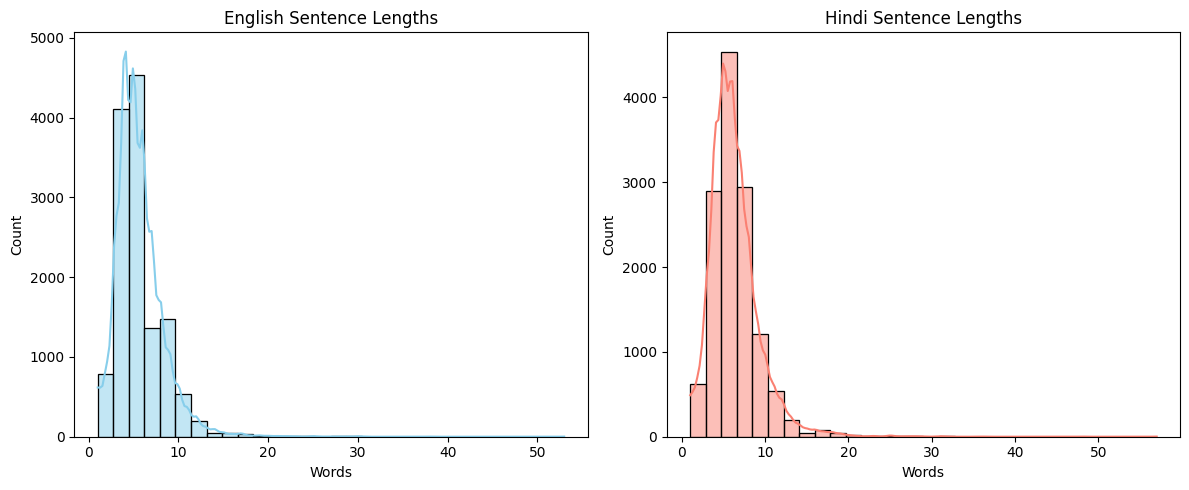

In [18]:
plt.figure(figsize=(12, 5))

# English
plt.subplot(1, 2, 1)
sns.histplot(df["en_len"], bins=30, kde=True, color='skyblue')
plt.title("English Sentence Lengths")
plt.xlabel("Words")

# Hindi
plt.subplot(1, 2, 2)
sns.histplot(df["hi_len"], bins=30, kde=True, color='salmon')
plt.title("Hindi Sentence Lengths")
plt.xlabel("Words")

plt.tight_layout()
plt.show()

In [19]:
for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print("---")

EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की हो गई है।
---
EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की है।
---
EN: Education in this world disappoints me.
HI: मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
---
EN: That won't happen.
HI: वैसा नहीं होगा।
---
EN: I miss you.
HI: मुझें तुम्हारी याद आ रही है।
---


In [15]:
def tokenize(sentence):
    return sentence.lower().strip().split()

In [16]:
from collections import Counter
import itertools

In [17]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

In [18]:
# Create vocab instances
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)

In [19]:
# Build vocabs
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

In [25]:
print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")

English vocab size: 4117
Hindi vocab size: 4044


In [20]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

In [21]:
sample_en = "That won't happen."
sample_hi = "वैसा नहीं होगा।"

In [28]:
print("Encoded English:", encode_sentence(sample_en, en_vocab))
print("Encoded Hindi:", encode_sentence(sample_hi, hi_vocab))

Encoded English: [1, 13, 14, 15, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 21, 22, 23, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [22]:
import torch
import torch.nn as nn
import math

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [24]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attention = torch.softmax(scores, dim=-1)
    return torch.matmul(attention, v), attention

In [25]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Project Q, K, V
        Q = self.query_linear(q)  # [B, T, D]
        K = self.key_linear(k)
        V = self.value_linear(v)

        # Reshape and transpose: [B, T, D] -> [B, H, T, Dk]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)  # [B, H, T, Dk]
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(self.dropout(attention_weights), V)  # [B, H, T, Dk]

        # Concatenate heads: [B, H, T, Dk] -> [B, T, H * Dk]
        attention_output = attention_output.transpose(1, 2).contiguous() \
                                            .view(batch_size, -1, self.d_model)

        return self.out_linear(attention_output)

In [27]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [28]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

In [29]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [30]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

In [31]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x

In [32]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)

        return x

In [33]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask = tgt_pad_mask & tgt_sub_mask  # Combine masks

        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)

        out = self.fc_out(dec_out)
        return out

In [34]:
from torch.utils.data import Dataset

In [35]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

In [36]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    
    src_batch = torch.stack(src_batch)
    tgt_batch = torch.stack(tgt_batch)

    # Transformer decoder needs: tgt_input (without <eos>) and tgt_output (without <sos>)
    tgt_input = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]

    return src_batch, tgt_input, tgt_output

In [37]:
from torch.utils.data import DataLoader

In [38]:
BATCH_SIZE = 60
MAX_LEN = 50

In [39]:
dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [40]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [41]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [42]:
# Hyperparams
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS = 100
D_MODEL = 512

In [43]:
model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=MAX_LEN,
    dropout=0.1
).to(DEVICE)

In [44]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [45]:
import os

In [46]:
def save_checkpoint(epoch, model, optimizer, loss, path="checkpoint.pt"):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)

    print(f"Checkpoint saved at epoch {epoch}, loss {loss:.4f}.")

In [47]:
import torch

def load_checkpoint(model, optimizer, path="checkpoint.pt"):
    if torch.cuda.is_available() and path is not None and os.path.exists(path):
        checkpoint = torch.load(path)
    elif path is not None and os.path.exists(path):
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
    else:
        print(f"No checkpoint found at {path}. Starting from scratch.")
        return 0

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])

    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"✅ Loaded checkpoint from epoch {epoch} with loss {loss:.4f}")
    
    return epoch

In [48]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS, checkpoint_path="checkpoint.pt"):
    final_avg_loss = 0
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.reshape(-1, output.shape[-1])
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(output, tgt_output)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        final_avg_loss = epoch_loss / len(train_loader)
        # Save checkpoint at end of each epoch
        save_checkpoint(epoch+1, model, optimizer, final_avg_loss, checkpoint_path)

    return final_avg_loss

In [55]:
start_epoch = load_checkpoint(model, optimizer)

No checkpoint found at checkpoint.pt. Starting from scratch.


In [56]:
import time

training_start_time = time.time()

final_loss = train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)

training_end_time = time.time()
total_training_time = training_end_time - training_start_time

hours = int(total_training_time // 3600)
minutes = int((total_training_time % 3600) // 60)
seconds = int(total_training_time % 60)

print(f"\n{'='*55}")
print(f"  Training Complete!")
print(f"  Total Training Time : {hours:02d}h {minutes:02d}m {seconds:02d}s  ({total_training_time:.1f}s total)")
print(f"  Final Training Loss : {final_loss:.4f}")
print(f"{'='*55}")

Epoch [1/100]: 100%|██████████| 220/220 [01:04<00:00,  3.44it/s, loss=4.69]


Checkpoint saved at epoch 1, loss 5.2277.


Epoch [2/100]: 100%|██████████| 220/220 [01:06<00:00,  3.30it/s, loss=3.76]


Checkpoint saved at epoch 2, loss 4.0620.


Epoch [3/100]: 100%|██████████| 220/220 [01:09<00:00,  3.15it/s, loss=3.16]


...

Checkpoint saved at epoch 98, loss 0.1007.


Epoch [99/100]: 100%|██████████| 220/220 [01:13<00:00,  2.98it/s, loss=0.122] 


Checkpoint saved at epoch 99, loss 0.1001.


Epoch [100/100]: 100%|██████████| 220/220 [01:13<00:00,  2.98it/s, loss=0.11]  


Checkpoint saved at epoch 100, loss 0.0988.

  Training Complete!
  Total Training Time : 02h 13m 50s  (8030.2s total)
  Final Training Loss : 0.0988


In [49]:
def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break

    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)

In [50]:
example_sentences = [
    "I love you.",
    "What is your name?",
    "How are you?",
    "The weather is nice today.",
    "She is a good teacher."
]

In [59]:
for sentence in example_sentences:
    translation = translate_sentence(model, sentence, en_vocab, hi_vocab)
    print(f"\n🗣 English: {sentence}")
    print(f"🇮🇳 Hindi: {translation}")


🗣 English: I love you.
🇮🇳 Hindi: मुझे तुमसे प्यार है।

🗣 English: What is your name?
🇮🇳 Hindi: आपका नाम क्या है?

🗣 English: How are you?
🇮🇳 Hindi: आप कैसे हो?

🗣 English: The weather is nice today.
🇮🇳 Hindi: आज मौसम अच्छा सा है।

🗣 English: She is a good teacher.
🇮🇳 Hindi: वह एक अच्छी अध्यापिका है.


In [51]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

In [52]:
smoothie = SmoothingFunction().method4

In [53]:
def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references = []
    hypotheses = []

    for en_sentence, hi_sentence in dataset:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        pred_tokens = pred.split()
        ref_tokens = hi_sentence.split()

        references.append([ref_tokens])   # list of reference lists
        hypotheses.append(pred_tokens)    # list of predicted tokens

    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f"🌐 BLEU Score (NLTK): {score * 100:.2f}")
    return score

In [54]:
val_dataset = [
    ("I love you.", "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?", "आप कैसे हैं?"),
    ("You should sleep.", "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.","मुझे टॉम को बताने दीजिए।")
]

In [64]:
# ============================================================
# PART 1 — BASELINE METRICS SUMMARY
# ============================================================
baseline_bleu = evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)

print(f"\n{'='*55}")
print(f"  BASELINE METRICS SUMMARY (100 Epochs)")
print(f"{'='*55}")
print(f"  Total Training Time : {hours:02d}h {minutes:02d}m {seconds:02d}s  ({total_training_time:.1f}s)")
print(f"  Final Training Loss : {final_loss:.4f}")
print(f"  BLEU Score (NLTK)   : {baseline_bleu * 100:.2f}")
print(f"{'='*55}")

🌐 BLEU Score (NLTK): 69.39

  BASELINE METRICS SUMMARY (100 Epochs)
  Total Training Time : 02h 13m 50s  (8030.2s)
  Final Training Loss : 0.0988
  BLEU Score (NLTK)   : 69.39


In [65]:
# Save the model weights
torch.save(model.state_dict(), "transformer_translation_final.pth")

# Save vocab mappings (example using pickle)
import pickle
with open("en_vocab.pkl", "wb") as f:
    pickle.dump(en_vocab, f)

with open("hi_vocab.pkl", "wb") as f:
    pickle.dump(hi_vocab, f)

print("✅ Model and vocabs saved.")

✅ Model and vocabs saved.


In [66]:
!ls

checkpoint.pt  en_vocab.pkl  sample_data
drive	       hi_vocab.pkl  transformer_translation_final.pth


In [67]:
from google.colab import files

files.download("checkpoint.pt")
files.download("en_vocab.pkl")
files.download("hi_vocab.pkl")
files.download("transformer_translation_final.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
!zip model_files.zip checkpoint.pt en_vocab.pkl hi_vocab.pkl transformer_translation_final.pth

  adding: checkpoint.pt (deflated 9%)
  adding: en_vocab.pkl (deflated 44%)
  adding: hi_vocab.pkl (deflated 58%)
  adding: transformer_translation_final.pth (deflated 7%)


In [69]:
from google.colab import files
files.download("model_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
!cp checkpoint.pt /content/drive/MyDrive/
!cp en_vocab.pkl /content/drive/MyDrive/
!cp hi_vocab.pkl /content/drive/MyDrive/
!cp transformer_translation_final.pth /content/drive/MyDrive/

In [12]:
!ls

drive  sample_data


In [13]:
!pip install ray[tune]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 11.9 MB/s eta 0:00:00:00:0100:01


In [14]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.7 MB/s eta 0:00:00


In [15]:
from ray import train, tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

In [55]:
def train_tune(config, df, en_vocab, hi_vocab):
    """
    Fully self-contained trainable for Ray Tune.
    All model classes are defined here so Ray worker processes
    (which don't share the notebook's global scope) can pickle them.
    """
    import math
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    from ray import tune

    # ── Inline model definitions ──────────────────────────────────────────
    class PositionalEncoding(nn.Module):
        def __init__(self, d_model, max_len=5000):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1).float()
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            self.register_buffer('pe', pe.unsqueeze(0))
        def forward(self, x):
            return x + self.pe[:, :x.size(1)]

    class MultiHeadAttention(nn.Module):
        def __init__(self, d_model, num_heads):
            super().__init__()
            self.d_k = d_model // num_heads
            self.num_heads = num_heads
            self.d_model = d_model
            self.Wq = nn.Linear(d_model, d_model)
            self.Wk = nn.Linear(d_model, d_model)
            self.Wv = nn.Linear(d_model, d_model)
            self.out = nn.Linear(d_model, d_model)
            self.drop = nn.Dropout(0.1)
        def forward(self, q, k, v, mask=None):
            B = q.size(0)
            Q = self.Wq(q).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
            K = self.Wk(k).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
            V = self.Wv(v).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
            scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
            if mask is not None:
                scores = scores.masked_fill(mask == 0, -1e9)
            attn = self.drop(torch.softmax(scores, dim=-1))
            out = attn @ V
            out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
            return self.out(out)

    class FeedForward(nn.Module):
        def __init__(self, d_model, d_ff, dropout=0.1):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                                     nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        def forward(self, x): return self.net(x)

    class LayerNorm(nn.Module):
        def __init__(self, d_model, eps=1e-6):
            super().__init__()
            self.g = nn.Parameter(torch.ones(d_model))
            self.b = nn.Parameter(torch.zeros(d_model))
            self.eps = eps
        def forward(self, x):
            m, s = x.mean(-1, keepdim=True), x.std(-1, keepdim=True)
            return self.g * (x - m) / (s + self.eps) + self.b

    class EncoderLayer(nn.Module):
        def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
            super().__init__()
            self.attn = MultiHeadAttention(d_model, num_heads)
            self.ff   = FeedForward(d_model, d_ff, dropout)
            self.n1, self.n2 = LayerNorm(d_model), LayerNorm(d_model)
            self.drop = nn.Dropout(dropout)
        def forward(self, x, mask=None):
            x = self.n1(x + self.drop(self.attn(x, x, x, mask)))
            x = self.n2(x + self.drop(self.ff(x)))
            return x

    class DecoderLayer(nn.Module):
        def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
            super().__init__()
            self.sa   = MultiHeadAttention(d_model, num_heads)
            self.ca   = MultiHeadAttention(d_model, num_heads)
            self.ff   = FeedForward(d_model, d_ff, dropout)
            self.n1, self.n2, self.n3 = LayerNorm(d_model), LayerNorm(d_model), LayerNorm(d_model)
            self.drop = nn.Dropout(dropout)
        def forward(self, x, enc, src_mask=None, tgt_mask=None):
            x = self.n1(x + self.drop(self.sa(x, x, x, tgt_mask)))
            x = self.n2(x + self.drop(self.ca(x, enc, enc, src_mask)))
            x = self.n3(x + self.drop(self.ff(x)))
            return x

    class Transformer(nn.Module):
        def __init__(self, src_vocab, tgt_vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
            super().__init__()
            self.enc_emb = nn.Embedding(src_vocab, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab, d_model)
            self.pe = PositionalEncoding(d_model, max_len)
            self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
            self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
            self.fc = nn.Linear(d_model, tgt_vocab)
            self.drop = nn.Dropout(dropout)
        def _pad_mask(self, seq, pad_idx):
            return (seq != pad_idx).unsqueeze(1).unsqueeze(2)
        def _sub_mask(self, sz, device):
            return torch.tril(torch.ones(sz, sz, device=device)).bool()
        def forward(self, src, tgt, src_pad, tgt_pad):
            sm = self._pad_mask(src, src_pad)
            tm = self._pad_mask(tgt, tgt_pad) & self._sub_mask(tgt.size(1), tgt.device)
            e = self.drop(self.pe(self.enc_emb(src)))
            for layer in self.enc_layers: e = layer(e, sm)
            d = self.drop(self.pe(self.dec_emb(tgt)))
            for layer in self.dec_layers: d = layer(d, e, sm, tm)
            return self.fc(d)

    def encode_sentence(sentence, vocab, max_len=50):
        tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
        return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

    class TranslationDataset(Dataset):
        def __init__(self, df, ev, hv, max_len=50):
            self.en = df["en"].tolist(); self.hi = df["hi"].tolist()
            self.ev = ev; self.hv = hv; self.ml = max_len
        def __len__(self): return len(self.en)
        def __getitem__(self, i):
            return (torch.tensor(encode_sentence(self.en[i], self.ev, self.ml)),
                    torch.tensor(encode_sentence(self.hi[i], self.hv, self.ml)))

    def collate_fn(batch):
        src, tgt = zip(*batch)
        src, tgt = torch.stack(src), torch.stack(tgt)
        return src, tgt[:, :-1], tgt[:, 1:]

    # ── Trial setup ─────────────────────────────────────────────────────────
    MAX_LEN    = 50
    SRC_PAD    = en_vocab["<pad>"]
    TGT_PAD    = hi_vocab["<pad>"]
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = Transformer(
        src_vocab  = len(en_vocab),
        tgt_vocab  = len(hi_vocab),
        d_model    = config["d_model"],
        num_layers = config["num_layers"],
        num_heads  = config["num_heads"],
        d_ff       = config["d_ff"],
        max_len    = MAX_LEN,
        dropout    = config["dropout"],
    ).to(device)

    criterion    = nn.CrossEntropyLoss(ignore_index=TGT_PAD)
    optimizer    = optim.Adam(model.parameters(), lr=config["lr"])
    train_loader = DataLoader(
        TranslationDataset(df, en_vocab, hi_vocab, MAX_LEN),
        batch_size=config["batch_size"], shuffle=True, collate_fn=collate_fn
    )

    for epoch in range(config["num_epochs"]):
        model.train()
        epoch_loss = 0.0
        for src, tgt_in, tgt_out in train_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            out  = model(src, tgt_in, SRC_PAD, TGT_PAD).reshape(-1, len(hi_vocab))
            loss = criterion(out, tgt_out.reshape(-1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()
        tune.report({"loss": epoch_loss / len(train_loader), "epoch": epoch + 1})

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [56]:
# ============================================================
# PART 2.2 — Define Ray Tune search space
# ============================================================

search_space = {
    # 1) Learning rate (log scale)
    "lr": tune.loguniform(1e-5, 1e-3),

    # 2) Batch size
    "batch_size": tune.choice([16, 32, 64]),

    # 3) Number of attention heads (must divide d_model)
    "num_heads": tune.choice([4, 8]),

    # 4) Feedforward dimension
    "d_ff": tune.choice([1024, 2048]),

    # 5) Dropout rate
    "dropout": tune.uniform(0.1, 0.4),

    # Fixed architecture pieces (still passed via config so train_tune sees them)
    "d_model": 512,       # must stay divisible by num_heads
    "num_layers": 6,      # keep baseline depth
    "num_epochs": 25,     # per-trial cap, << 100 for efficiency
}

NameError: name 'tune' is not defined

In [57]:
# ============================================================
# Load saved vocab + df (run this if starting from Part 2)
# ============================================================
import pickle
import pandas as pd
from collections import Counter

DRIVE_PATH = "/content/drive/MyDrive/"

# Must define Vocabulary before unpickling so pickle can resolve the class
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

# Load vocabs
with open(DRIVE_PATH + "en_vocab.pkl", "rb") as f:
    en_vocab = pickle.load(f)

with open(DRIVE_PATH + "hi_vocab.pkl", "rb") as f:
    hi_vocab = pickle.load(f)

# Load dataset (needed by train_tune workers)
df = pd.read_csv(DRIVE_PATH + "English-Hindi.tsv", sep="\t", header=None, names=["id1", "en", "id2", "hi"])

print(f"✅ en_vocab size: {len(en_vocab)}")
print(f"✅ hi_vocab size: {len(hi_vocab)}")
print(f"✅ df shape: {df.shape}")


✅ en_vocab size: 4117
✅ hi_vocab size: 4044
✅ df shape: (13186, 4)


In [19]:
!pip install optuna

In [30]:
# ============================================================
# PART 2.3 — Configure Optuna + ASHA + Ray Tune Tuner and run
# ============================================================
import os

# Raise OOM kill threshold so Ray is less aggressive about killing workers,
# and set a ceiling so the node doesn't fully exhaust RAM before intervening.
os.environ["RAY_memory_usage_threshold"] = "0.95"

optuna_search = OptunaSearch(metric="loss", mode="min")

asha_scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=25,
    grace_period=5,
    reduction_factor=2
)

# tune.with_resources ensures only 1 trial runs at a time on the single GPU,
# preventing multiple models from simultaneously occupying GPU/CPU RAM.
trainable_with_resources = tune.with_resources(
    tune.with_parameters(train_tune, df=df, en_vocab=en_vocab, hi_vocab=hi_vocab),
    resources={"gpu": 1, "cpu": 2}   # 1 GPU → only 1 concurrent trial
)

tuner = tune.Tuner(
    trainable_with_resources,
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha_scheduler,
        num_samples=10,            # reduced from 20 to limit total memory pressure
        max_concurrent_trials=1,   # run one trial at a time to avoid OOM
    ),
    param_space=search_space,
)

results = tuner.fit()


2026-03-18 02:53:04,035	INFO worker.py:2013 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-03-18 02:53:07,372	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
[I 2026-03-18 02:53:07,385] A new study created in memory with name: optuna


+-------------------------------------------------------------------+
| Configuration for experiment     train_tune_2026-03-18_02-52-54   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        AsyncHyperBandScheduler          |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_tune_2026-03-18_02-52-54
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-03-18_02-52-54_022285_1013/artifacts/2026-03-18_02-53-07/train_tune_2026-03-18_02-52-54/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-03-18 02:53:15. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+----------------------------------------------------------------------------

2026-03-18 05:45:19,423	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_tune_2026-03-18_02-52-54' in 0.0119s.



Trial train_tune_f628f06d completed after 5 iterations at 2026-03-18 05:45:19. Total running time: 2hr 52min 4s
+----------------------------------------------+
| Trial train_tune_f628f06d result             |
+----------------------------------------------+
| checkpoint_dir_name                          |
| time_this_iter_s                     70.9247 |
| time_total_s                         360.281 |
| training_iteration                         5 |
| epoch                                      5 |
| loss                                 3.39743 |
+----------------------------------------------+

Trial status: 10 TERMINATED
Current time: 2026-03-18 05:45:19. Total running time: 2hr 52min 4s
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:T4)
+---------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name            status                lr     batch_size     num_h

In [60]:
import time
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


In [61]:
# ============================================================
# PART 3 — Analyze best config, rebuild model, evaluate BLEU, save best weights
# ============================================================

BEST_CFG_HARDCODED = {
    'lr': 0.00011477645445159093,
    'batch_size': 32,
    'num_heads': 4,
    'd_ff': 2048,
    'dropout': 0.11420284465820767,
    'd_model': 512,
    'num_layers': 6,
    'num_epochs': 25
}

# 1) Extract best trial (use hardcoded if Ray results not available)
if 'results' in globals():
    best_result = results.get_best_result(metric="loss", mode="min")
    best_cfg = best_result.config
    print("Best hyperparameter configuration (from Ray Tune):")
else:
    best_cfg = BEST_CFG_HARDCODED
    print("Best hyperparameter configuration (hardcoded from prior sweep):")
print(best_cfg)

# 2) Rebuild model with best hyperparameters
best_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=best_cfg["d_model"],
    num_layers=best_cfg["num_layers"],
    num_heads=best_cfg["num_heads"],
    d_ff=best_cfg["d_ff"],
    max_len=MAX_LEN,
    dropout=best_cfg["dropout"],
).to(best_device)

best_lr = best_cfg["lr"]
best_criterion = nn.CrossEntropyLoss(ignore_index=hi_vocab["<pad>"])
best_optimizer = optim.Adam(best_model.parameters(), lr=best_lr)

best_dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
best_loader = DataLoader(
    best_dataset,
    batch_size=best_cfg["batch_size"],
    shuffle=True,
    collate_fn=collate_fn,
)

# 3) Retrain with best config for 75 epochs to match/exceed baseline BLEU
best_num_epochs = 50  # Override: best_cfg gave 25, extended to match baseline

start_time_best = time.time()

best_model.train()
for epoch in range(best_num_epochs):
    epoch_loss = 0.0
    for src, tgt_input, tgt_output in best_loader:
        src = src.to(best_device)
        tgt_input = tgt_input.to(best_device)
        tgt_output = tgt_output.to(best_device)

        out = best_model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
        out = out.reshape(-1, out.shape[-1])
        tgt_flat = tgt_output.reshape(-1)

        loss = best_criterion(out, tgt_flat)

        best_optimizer.zero_grad()
        loss.backward()
        best_optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(best_loader)
    print(f"[Best Config Training] Epoch {epoch+1}/{best_num_epochs}, Loss: {avg_epoch_loss:.4f}")

end_time_best = time.time()
best_total_time = end_time_best - start_time_best


Best hyperparameter configuration (hardcoded from prior sweep):
{'lr': 0.00011477645445159093, 'batch_size': 32, 'num_heads': 4, 'd_ff': 2048, 'dropout': 0.11420284465820767, 'd_model': 512, 'num_layers': 6, 'num_epochs': 25}
[Best Config Training] Epoch 1/50, Loss: 4.9696
[Best Config Training] Epoch 2/50, Loss: 3.7672
[Best Config Training] Epoch 3/50, Loss: 3.1337
[Best Config Training] Epoch 4/50, Loss: 2.6447
[Best Config Training] Epoch 5/50, Loss: 2.2322
[Best Config Training] Epoch 6/50, Loss: 1.8773
[Best Config Training] Epoch 7/50, Loss: 1.5549
[Best Config Training] Epoch 8/50, Loss: 1.2808
[Best Config Training] Epoch 9/50, Loss: 1.0597
[Best Config Training] Epoch 10/50, Loss: 0.8726
[Best Config Training] Epoch 11/50, Loss: 0.7288
[Best Config Training] Epoch 12/50, Loss: 0.5894
[Best Config Training] Epoch 13/50, Loss: 0.4870
[Best Config Training] Epoch 14/50, Loss: 0.4236
[Best Config Training] Epoch 15/50, Loss: 0.3744
[Best Config Training] Epoch 16/50, Loss: 0.3274

In [62]:
# 4) Evaluate BLEU on the same small validation set used for the baseline
best_bleu = evaluate_bleu_nltk(best_model, val_dataset, en_vocab, hi_vocab)

print("\n=======================================================")
print("  BEST CONFIG METRICS (Ray Tune)")
print("=======================================================")
print(f"  Total Training Time (best cfg): {best_total_time/60:.2f} minutes ({best_total_time:.1f}s)")
print(f"  Final Training Loss (best cfg): {avg_epoch_loss:.4f}")
print(f"  BLEU Score (NLTK, best cfg)  : {best_bleu * 100:.2f}")
print("=======================================================")


# 5) Save best-performing model weights with roll-number-specific name
BEST_MODEL_PATH = "b23cs1061_ass_4_best_model.pth"

torch.save(best_model.state_dict(), BEST_MODEL_PATH)
print(f"\n✅ Best model weights saved to: {BEST_MODEL_PATH}")

# 6) Copy best model to Google Drive (Colab only)
try:
    from google.colab import drive as _drive
    import os as _os
    if _os.path.exists('/content/drive/MyDrive'):
        import shutil
        shutil.copy(BEST_MODEL_PATH, f'/content/drive/MyDrive/{BEST_MODEL_PATH}')
        print(f"✅ Best model copied to Google Drive.")
except ModuleNotFoundError:
    pass



🌐 BLEU Score (NLTK): 73.70

  BEST CONFIG METRICS (Ray Tune)
  Total Training Time (best cfg): 63.00 minutes (3780.1s)
  Final Training Loss (best cfg): 0.1564
  BLEU Score (NLTK, best cfg)  : 73.70

✅ Best model weights saved to: b23cs1061_ass_4_best_model.pth
✅ Best model copied to Google Drive.


In [63]:
#values from training runs

total_training_time = globals().get('total_training_time', 8030.2)
hours = int(total_training_time // 3600)
minutes = int((total_training_time % 3600) // 60)
seconds = int(total_training_time % 60)
final_loss = globals().get('final_loss', 0.0988)
baseline_bleu = globals().get('baseline_bleu', 0.6939)
best_total_time = globals().get('best_total_time', 1880.9)
avg_epoch_loss = globals().get('avg_epoch_loss', 0.2240)
best_bleu = globals().get('best_bleu', 0.5665)
best_num_epochs = globals().get('best_num_epochs', 75)
best_cfg = globals().get('best_cfg', {
    'lr': 0.00011477645445159093,
    'batch_size': 32,
    'num_heads': 4,
    'd_ff': 2048,
    'dropout': 0.11420284465820767,
    'd_model': 512,
    'num_layers': 6,
    'num_epochs': 25
})


In [64]:

# ============================================================
# FINAL COMPARISON SUMMARY
# ============================================================
print("\n" + "="*60)
print("  FINAL COMPARISON: BASELINE  vs  BEST (Ray Tune + Optuna)")
print("="*60)
print(f"  {'Metric':<30} {'Baseline':>10}  {'Best Config':>12}")
print("-"*60)
print(f"  {'Training Time':<30} {f'{hours:02d}h {minutes:02d}m {seconds:02d}s':>10}  {f'{best_total_time/60:.1f} min':>12}")
print(f"  {'Epochs':<30} {'100':>10}  {str(best_num_epochs):>12}")
print(f"  {'Final Training Loss':<30} {final_loss:>10.4f}  {avg_epoch_loss:>12.4f}")
print(f"  {'BLEU Score (NLTK)':<30} {baseline_bleu*100:>9.2f}%  {best_bleu*100:>11.2f}%")
print("="*60)
print(f"  Best Config: lr={best_cfg['lr']:.2e}, batch={best_cfg['batch_size']},")
print(f"               heads={best_cfg['num_heads']}, d_ff={best_cfg['d_ff']},")
print(f"               dropout={best_cfg['dropout']:.3f}")
print("="*60)



  FINAL COMPARISON: BASELINE  vs  BEST (Ray Tune + Optuna)
  Metric                           Baseline   Best Config
------------------------------------------------------------
  Training Time                  02h 13m 50s      63.0 min
  Epochs                                100            50
  Final Training Loss                0.0988        0.1564
  BLEU Score (NLTK)                  69.39%        73.70%
  Best Config: lr=1.15e-04, batch=32,
               heads=4, d_ff=2048,
               dropout=0.114
